### __Chain__
* __Review__ - 
We built a simple graph with nodes, normal edges, and conditional edges.



Simple chain that combines 4 concepts.

* Using __chat messages__ as our graph state
* Using __chat models__ in graph nodes
* __Binding tools__ to our chat model
* __Executing tool calls__ in graph nodes

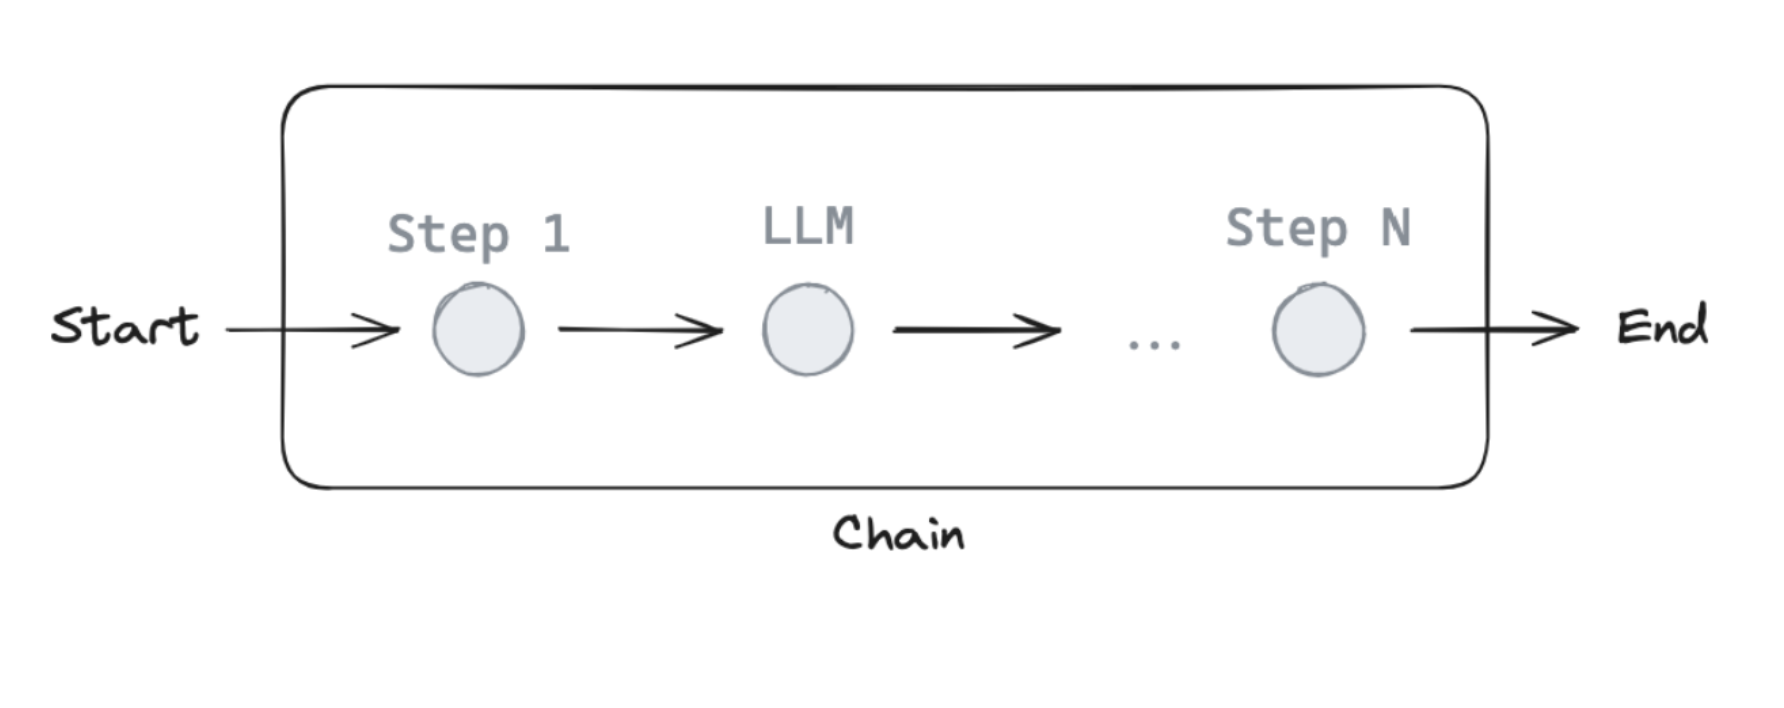

### __Messages__
Chat models can use `messages`, which capture different roles within a conversation.

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`.

These __represent a message from the user__, from chat model, for the chat model to instruct behavior, and from a tool call.

Let's create a list of messages.

Each message can be supplied with a few things:

`content` - content of the message\
`name` - optionally, a message author\
`response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for _AIMessages_)

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching Generative AI ?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Abdullah"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best practices for using Generative AI.", name="Abdullah"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching Generative AI ?
================================ Human Message =================================
Name: Abdullah

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Abdullah

I want to learn about the best practices for using Generative AI.


### __Chat Models__
Chat models use a sequence of messages as input and support message types, as discussed above.

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
NV_API_KEY = os.getenv("NV_API_KEY")
NV_API_URL = os.getenv("NV_API_URL")

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    openai_api_key=NV_API_KEY,
    openai_api_base=NV_API_URL,
    temperature=0.001,
    top_p=1,
    max_tokens=4096,
    streaming=False,
    extra_body={"reasoning_effort": "low"}
)

In [5]:
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [8]:
result

AIMessage(content='Below is a **concise, actionable playbook** you can use right away—whether you’re a product manager, data scientist, developer, marketer, or an executive who wants to embed generative‑AI (Gen‑AI) safely and effectively into your workflow or product.  \n\n---\n\n## 1️⃣ Foundations\u202f—\u202fWhy “best‑practice” matters\n\n| Goal | What it solves | Typical failure mode |\n|------|----------------|----------------------|\n| **Reliability** | Consistent, repeatable outputs | “Hallucinations” or wildly variable answers |\n| **Safety & Ethics** | Avoid bias, privacy breaches, misuse | Discriminatory content, data leakage |\n| **Scalability** | Cost‑effective serving at production scale | Unexpected spikes in latency or spend |\n| **User Trust** | Transparent, explainable AI | Black‑box perception, loss of credibility |\n| **Compliance** | Meet GDPR, CCPA, industry‑specific regs | Legal penalties, brand damage |\n\n---\n\n## 2️⃣ End‑to‑End Workflow & Checklist  \n\n| Phase

In [7]:
result.pretty_print()

================================== Ai Message ==================================

Below is a **concise, actionable playbook** you can use right away—whether you’re a product manager, data scientist, developer, marketer, or an executive who wants to embed generative‑AI (Gen‑AI) safely and effectively into your workflow or product.  

---

## 1️⃣ Foundations — Why “best‑practice” matters

| Goal | What it solves | Typical failure mode |
|------|----------------|----------------------|
| **Reliability** | Consistent, repeatable outputs | “Hallucinations” or wildly variable answers |
| **Safety & Ethics** | Avoid bias, privacy breaches, misuse | Discriminatory content, data leakage |
| **Scalability** | Cost‑effective serving at production scale | Unexpected spikes in latency or spend |
| **User Trust** | Transparent, explainable AI | Black‑box perception, loss of credibility |
| **Compliance** | Meet GDPR, CCPA, industry‑specific regs | Legal penalties, brand damage |

---

## 2️⃣ End‑to‑

In [12]:
result.response_metadata

{'token_usage': {'completion_tokens': 3448,
  'prompt_tokens': 120,
  'total_tokens': 3568,
  'completion_tokens_details': None,
  'prompt_tokens_details': None},
 'model_provider': 'openai',
 'model_name': 'openai/gpt-oss-120b',
 'system_fingerprint': None,
 'id': 'chatcmpl-bbe0f9d99d5fb356',
 'finish_reason': 'stop',
 'logprobs': None}

### __Tools__
Tools are useful whenever you want a model to interact with external systems.

`External systems` (e.g., APIs) often require a particular `input schema` or `payload`, rather than natural language.

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool __based upon the natural language input__ from the user.

And, it will return an __output that adheres to the tool's schema__.

Many LLM providers support tool calling and tool calling interface in LangChain is simple.

You can simply pass any Python function into `ChatModel.bind_tools(function)`.

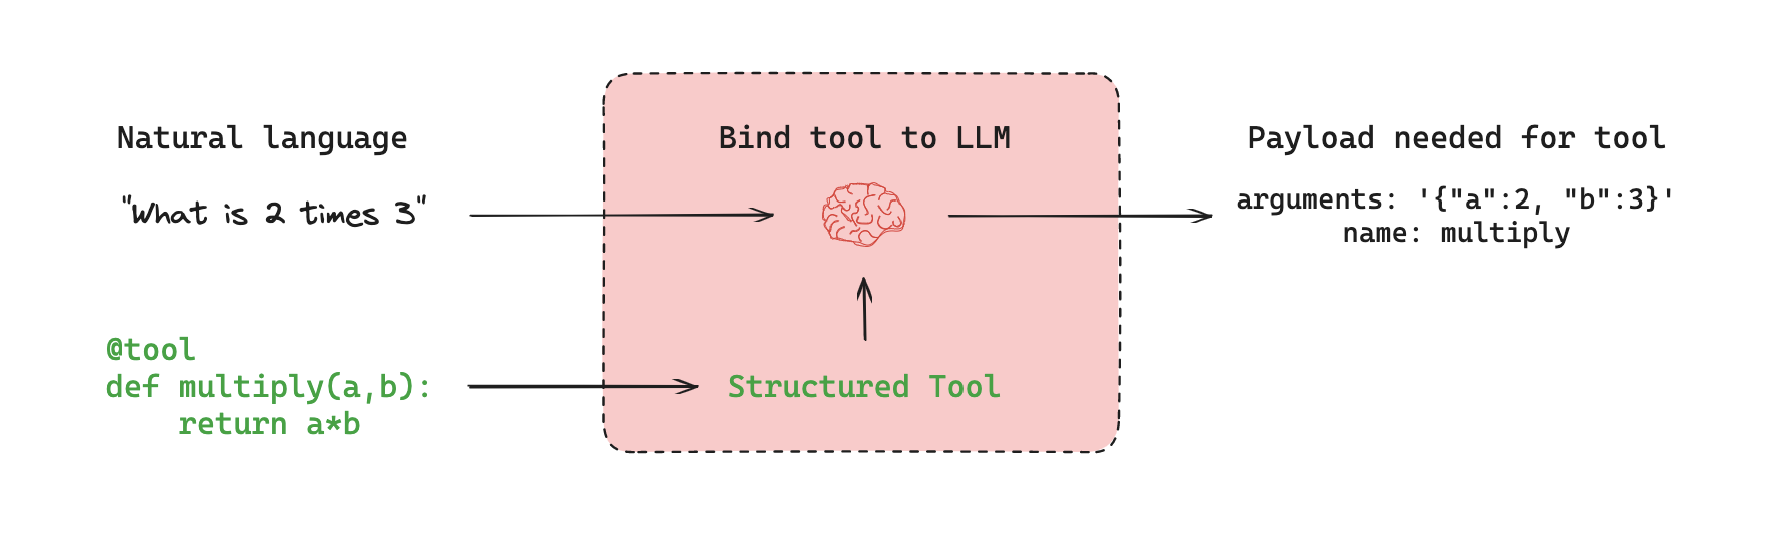

The multiply function is our tool.

In [13]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., "`What is 2 multiplied by 3`" - we see a tool call returned.

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

__{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}__

In [14]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Abdullah")])

In [16]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'chatcmpl-tool-b35f333a407fb3ef',
  'type': 'tool_call'}]

### __Using messages as state__
With these foundations in place, we can now use `messages` in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

messages is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [17]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

### __Reducers__
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will overwrite the prior messages value!

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

`Reducers` specify __how state updates are performed__.

If `no reducer function` is specified, then it is assumed that __updates to the key should override__ it as we saw before.

But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [18]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built `MessagesState`!

`MessagesState` is defined:

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects
* It uses the `add_messages` reducer\
We'll usually use `MessagesState` because it is __less verbose__ than defining a custom TypedDict, as shown above.

In [19]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [20]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on RAG frameworks.", name="Abdullah")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='939a244f-bf5d-4ac5-b1b7-5d507e0656b5', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on RAG frameworks.", additional_kwargs={}, response_metadata={}, name='Abdullah', id='4758fecd-c0e9-4feb-99a0-ea57c820096c'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='c135de8d-18cf-42a2-8b8a-c5f5f01ca73d', tool_calls=[], invalid_tool_calls=[])]

#### __Our graph__

Now, lets use `MessagesState` with a graph.

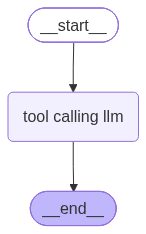

In [21]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool calling llm", tool_calling_llm)
builder.add_edge(START, "tool calling llm")
builder.add_edge("tool calling llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [22]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! How can I assist you today?


In [25]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 6 and 5")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 6 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-9174eb1b4f1e0c6b)
 Call ID: chatcmpl-tool-9174eb1b4f1e0c6b
  Args:
    a: 6
    b: 5
